# v4 final: complex-weighted LateralizedHopfModelVM, sweep-winning config

This notebook is the complete record of the final `v4` model: the network
architecture (complex-weighted V-section + M-section, rest/motion padding),
the 16-config hyperparameter sweep that picked its settings, and the
resulting fully-trained model's predictions.

**This notebook loads the already-trained checkpoint rather than retraining
live** -- the final run took ~2.1 hours (500-epoch budget, early-stopped at
epoch 286) via the standalone `sweep_train.py` script. The `train()`
function below is the exact code that produced it; it's included in full
so the model is reproducible, but the heavy call itself isn't re-triggered
here.

In [1]:
import json
import random
import pickle
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from complexPyTorch.complexLayers import ComplexLinear, ComplexReLU

PROJECT_ROOT = Path.cwd().parent
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## `HopfCell`

Bank of independent Hopf oscillators (`mu=1, beta=-1` fixed, frequencies
fixed across the mu band 8-13Hz, not learnable), native complex I/O.
Unchanged since `v2`.

In [2]:
class HopfCell(nn.Module):
    MU = 1.0
    BETA = -1.0

    def __init__(self, units=50, min_freq=8.0, max_freq=13.0, dt=0.01, input_scaler=5.0):
        super().__init__()
        self.units = units
        self.dt = dt
        self.input_scaler = input_scaler
        freqs = torch.linspace(min_freq, max_freq, units)
        self.register_buffer("omega", 2 * np.pi * freqs)

    def init_state(self, batch_size, device):
        r = torch.ones(batch_size, self.units, device=device)
        phi = torch.zeros(batch_size, self.units, device=device)
        return r, phi

    def forward(self, drive, r, phi, phase_coupling=None):
        drive_r = self.input_scaler * drive.real * torch.cos(phi)
        drive_phi = self.input_scaler * drive.imag * torch.sin(phi)
        r_next = r + (self.MU * r + self.BETA * r**3 + drive_r) * self.dt
        coupling = phase_coupling if phase_coupling is not None else 0.0
        phi_next = phi + (self.omega.unsqueeze(0) - drive_phi - coupling) * self.dt
        z = torch.complex(r_next * torch.cos(phi_next), r_next * torch.sin(phi_next))
        return z, r_next, phi_next

## `LateralizedHopfModelVM` (V + M, genuinely complex)

The V-section (`v1 -> v2 crossing -> v3`) and the drive projection into
each oscillator population are `ComplexLinear`/`ComplexReLU` -- true
complex weights (`W_r + iW_i`), mirroring the finalized
`1d_track_concat_inv_vis_sweep_best` architecture from the spatial
navigation sweep, rather than two independent real projections labeled
"real"/"imag". The readout keeps the winning **concatenated** style
(`cat([z.real, z.imag])` into a real Linear) rather than magnitude-only.

Input now carries a 7th value: `moving_flag` (0 = at rest, 1 = in motion),
so the network is explicitly told whether it should be holding still or
reaching.

In [3]:
class LateralizedHopfModelVM(nn.Module):

    def __init__(self, n_osc_per_side=50, v_hidden=32, dt=0.005, input_scaler=5.0,
                 min_freq=8.0, max_freq=13.0, kappa=0.5, readout_hidden=32):
        super().__init__()
        self.n_osc = n_osc_per_side
        self.kappa = kappa

        self.v1_L = ComplexLinear(5, v_hidden)
        self.v1_R = ComplexLinear(5, v_hidden)
        self.v2_own_L = ComplexLinear(v_hidden, v_hidden)
        self.v2_cross_R = ComplexLinear(v_hidden, v_hidden)
        self.v2_own_R = ComplexLinear(v_hidden, v_hidden)
        self.v2_cross_L = ComplexLinear(v_hidden, v_hidden)
        self.v3_L = ComplexLinear(v_hidden, v_hidden)
        self.v3_R = ComplexLinear(v_hidden, v_hidden)
        self.crelu = ComplexReLU()

        self.to_drive_L = ComplexLinear(v_hidden, n_osc_per_side)
        self.to_drive_R = ComplexLinear(v_hidden, n_osc_per_side)

        self.hopf_L = HopfCell(units=n_osc_per_side, min_freq=min_freq, max_freq=max_freq,
                                dt=dt, input_scaler=input_scaler)
        self.hopf_R = HopfCell(units=n_osc_per_side, min_freq=min_freq, max_freq=max_freq,
                                dt=dt, input_scaler=input_scaler)

        self.readout_L = nn.Sequential(
            nn.Linear(2 * n_osc_per_side, readout_hidden), nn.LeakyReLU(),
            nn.Linear(readout_hidden, 2),
        )
        self.readout_R = nn.Sequential(
            nn.Linear(2 * n_osc_per_side, readout_hidden), nn.LeakyReLU(),
            nn.Linear(readout_hidden, 2),
        )

    def init_state(self, batch_size, device):
        r_L, phi_L = self.hopf_L.init_state(batch_size, device)
        r_R, phi_R = self.hopf_R.init_state(batch_size, device)
        return (r_L, phi_L, r_R, phi_R)

    def visual_encode(self, x):
        target = x[:, 4:6]
        moving = x[:, 6:7]
        in_L = torch.cat([x[:, 0:2], target, moving], dim=1)
        in_R = torch.cat([x[:, 2:4], target, moving], dim=1)
        in_L_c = torch.complex(in_L, torch.zeros_like(in_L))
        in_R_c = torch.complex(in_R, torch.zeros_like(in_R))
        h1_L = self.crelu(self.v1_L(in_L_c))
        h1_R = self.crelu(self.v1_R(in_R_c))
        h2_L = self.crelu(self.v2_own_L(h1_L) + self.v2_cross_R(h1_R))
        h2_R = self.crelu(self.v2_own_R(h1_R) + self.v2_cross_L(h1_L))
        h3_L = self.crelu(self.v3_L(h2_L))
        h3_R = self.crelu(self.v3_R(h2_R))
        return h3_L, h3_R

    def forward_step(self, x, state, return_diagnostics=False):
        r_L, phi_L, r_R, phi_R = state
        enc_L, enc_R = self.visual_encode(x)
        drive_L = self.to_drive_L(enc_L)
        drive_R = self.to_drive_R(enc_R)

        z_L_now = torch.complex(r_L * torch.cos(phi_L), r_L * torch.sin(phi_L))
        z_R_now = torch.complex(r_R * torch.cos(phi_R), r_R * torch.sin(phi_R))
        psi_L = torch.angle(z_L_now.mean(dim=1, keepdim=True))
        psi_R = torch.angle(z_R_now.mean(dim=1, keepdim=True))

        coupling_into_L = self.kappa * torch.sin(psi_R - phi_L)
        coupling_into_R = self.kappa * torch.sin(psi_L - phi_R)

        z_L, r_L_next, phi_L_next = self.hopf_L(drive_L, r_L, phi_L, phase_coupling=coupling_into_L)
        z_R, r_R_next, phi_R_next = self.hopf_R(drive_R, r_R, phi_R, phase_coupling=coupling_into_R)

        feat_L = torch.cat([z_L.real, z_L.imag], dim=1)
        feat_R = torch.cat([z_R.real, z_R.imag], dim=1)
        pred = torch.cat([self.readout_L(feat_L), self.readout_R(feat_R)], dim=1)
        new_state = (r_L_next, phi_L_next, r_R_next, phi_R_next)

        if return_diagnostics:
            diag = {"z_L": z_L, "z_R": z_R, "r_L": r_L_next, "r_R": r_R_next,
                    "phi_L": phi_L_next, "phi_R": phi_R_next}
            return pred, new_state, diag
        return pred, new_state

## `TrajectoryDataset` -- with rest/motion padding

Each 100-step reach is padded with 20 genuinely held-still rest steps
before and after (hand frozen at the trajectory's own start/end position),
paired with a ground-truth `moving_flag`.

In [4]:
class TrajectoryDataset(Dataset):

    def __init__(self, root_dir, pad_pre=20, pad_post=20):
        root_dir = Path(root_dir)
        self.pad_pre = pad_pre
        self.pad_post = pad_post
        with open(root_dir / "data" / "raw" / "splined_trajectories_100.txt", "rb") as f:
            self.trajectories = pickle.load(f)
        with open(root_dir / "data" / "processed" / "targets_100.pkl", "rb") as f:
            self.targets = pickle.load(f)
        with open(root_dir / "data" / "processed" / "active_arms_100.pkl", "rb") as f:
            self.active_arms = pickle.load(f)
        assert len(self.trajectories) == len(self.targets) == len(self.active_arms)

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = np.asarray(self.trajectories[idx], dtype=np.float32)
        target = np.asarray(self.targets[idx], dtype=np.float32)
        active_arm = np.int64(self.active_arms[idx])
        pre = np.repeat(traj[0:1], self.pad_pre, axis=0)
        post = np.repeat(traj[-1:], self.pad_post, axis=0)
        traj_padded = np.concatenate([pre, traj, post], axis=0)
        moving_flag = np.concatenate([
            np.zeros(self.pad_pre, dtype=np.float32),
            np.ones(traj.shape[0], dtype=np.float32),
            np.zeros(self.pad_post, dtype=np.float32),
        ])
        return (torch.from_numpy(traj_padded), torch.from_numpy(target),
                torch.from_numpy(moving_flag), torch.tensor(active_arm))

## Training function

Scheduled sampling (teacher forcing annealed `1.0 -> 0.1`), gradient
clipping, best-val-loss checkpointing with full oscillator-state
diagnostics, early stopping on patience. Defaults below are the
**sweep-winning hyperparameters**.

In [5]:
def teacher_forcing_prob(epoch, epochs, start=1.0, end=0.1):
    frac = (epoch - 1) / max(1, epochs - 1)
    return start + (end - start) * frac


def collect_oscillator_states(traj_batch, target_batch, moving_batch, model, device):
    B, T = traj_batch.shape[0], traj_batch.shape[1]
    state = model.init_state(batch_size=B, device=device)
    prev = traj_batch[:, 0]
    rec = {side: {"z_real": [], "z_imag": [], "r": [], "phi": []} for side in ("L", "R")}
    for t in range(1, T):
        moving_t = moving_batch[:, t:t + 1]
        inp = torch.cat([prev, target_batch, moving_t], dim=1)
        pred, state, diag = model.forward_step(inp, state, return_diagnostics=True)
        for side in ("L", "R"):
            rec[side]["z_real"].append(diag[f"z_{side}"].real.detach().cpu().numpy())
            rec[side]["z_imag"].append(diag[f"z_{side}"].imag.detach().cpu().numpy())
            rec[side]["r"].append(diag[f"r_{side}"].detach().cpu().numpy())
            rec[side]["phi"].append(diag[f"phi_{side}"].detach().cpu().numpy())
        prev = pred
    out = {}
    for side in ("L", "R"):
        for k in ("z_real", "z_imag", "r", "phi"):
            out[f"{k}_{side}"] = np.stack(rec[side][k], axis=0).transpose(1, 0, 2)
    return out


def train(output_dir, epochs=500, batch_size=32, learning_rate=1e-3, seed=42,
          n_osc_per_side=50, v_hidden=32, dt=0.005, input_scaler=5.0,
          freq_min=8.0, freq_max=13.0, kappa=0.5, readout_hidden=32,
          teacher_forcing_start=1.0, teacher_forcing_end=0.1,
          pad_pre=20, pad_post=20, patience=50, save_full_diagnostics=True):
    output_dir = Path(output_dir)
    figure_dir = output_dir / "figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    figure_dir.mkdir(parents=True, exist_ok=True)

    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    dataset = TrajectoryDataset(PROJECT_ROOT, pad_pre=pad_pre, pad_post=pad_post)
    train_size = int(0.8 * len(dataset)); val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size], generator=torch.Generator().manual_seed(seed))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = LateralizedHopfModelVM(
        n_osc_per_side=n_osc_per_side, v_hidden=v_hidden, dt=dt, input_scaler=input_scaler,
        min_freq=freq_min, max_freq=freq_max, kappa=kappa, readout_hidden=readout_hidden,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()
    history = {"train_loss": [], "val_loss": [], "teacher_forcing": []}
    best_val_loss = float("inf"); epochs_since_improve = 0; best_epoch = 0

    for epoch in range(1, epochs + 1):
        tf_prob = teacher_forcing_prob(epoch, epochs, teacher_forcing_start, teacher_forcing_end)
        model.train(); train_loss_epoch = 0.0

        for traj_batch, target_batch, moving_batch, _ in train_loader:
            traj_batch, target_batch, moving_batch = traj_batch.to(device), target_batch.to(device), moving_batch.to(device)
            B, T = traj_batch.shape[0], traj_batch.shape[1]
            state = model.init_state(batch_size=B, device=device)
            prev = traj_batch[:, 0]; loss = 0.0
            optimizer.zero_grad()
            for t in range(1, T):
                moving_t = moving_batch[:, t:t + 1]
                inp = torch.cat([prev, target_batch, moving_t], dim=1)
                pred, state = model.forward_step(inp, state)
                gt = traj_batch[:, t]
                loss += loss_fn(pred, gt)
                prev = gt if random.random() < tf_prob else pred.detach()
            loss = loss / (T - 1)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss_epoch += loss.item()
        train_loss_epoch /= len(train_loader)

        model.eval(); val_loss_epoch = 0.0
        with torch.no_grad():
            for traj_batch, target_batch, moving_batch, _ in val_loader:
                traj_batch, target_batch, moving_batch = traj_batch.to(device), target_batch.to(device), moving_batch.to(device)
                B, T = traj_batch.shape[0], traj_batch.shape[1]
                state = model.init_state(batch_size=B, device=device)
                prev = traj_batch[:, 0]; loss = 0.0
                for t in range(1, T):
                    moving_t = moving_batch[:, t:t + 1]
                    inp = torch.cat([prev, target_batch, moving_t], dim=1)
                    pred, state = model.forward_step(inp, state)
                    gt = traj_batch[:, t]
                    loss += loss_fn(pred, gt)
                    prev = pred
                loss = loss / (T - 1)
                val_loss_epoch += loss.item()
        val_loss_epoch /= len(val_loader)

        history["train_loss"].append(train_loss_epoch)
        history["val_loss"].append(val_loss_epoch)
        history["teacher_forcing"].append(tf_prob)

        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch; best_epoch = epoch; epochs_since_improve = 0
            torch.save({"epoch": epoch, "val_loss": val_loss_epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict()},
                       output_dir / "best_hopf_model.pt")
        else:
            epochs_since_improve += 1
        if epochs_since_improve >= patience:
            break

    with open(output_dir / "history.json", "w") as f:
        json.dump(history, f)
    return model, history, best_val_loss, best_epoch

## The hyperparameter sweep

16 configs: `learning_rate` {1e-3, 3e-4} x `kappa` {0.5, 1.5} x
`n_osc_per_side` {25, 50} x `v_hidden` {16, 32}, fixed `readout_hidden=32`,
batch=32, TF anneal 1.0->0.1, up to 250 epochs with patience=30. Run
across 10 concurrent GPU slots (GPUs 4 & 5 dedicated, one slot each on
GPUs 0,1,2,3,6,7 as leftover capacity alongside other jobs already
running there). Leaderboard below is read directly from each config's
saved `metrics.json` -- not retyped by hand.

In [6]:
SWEEP_DIR = PROJECT_ROOT / "outputs_v4_sweep"
rows = []
for d in sorted(SWEEP_DIR.iterdir()):
    mpath = d / "metrics.json"
    if mpath.exists():
        with open(mpath) as f:
            m = json.load(f)
        rows.append((m["best_val_loss"], d.name, m["best_epoch"], m["epochs_run"], m["config"]))

rows.sort(key=lambda r: r[0])
print(f"{'val_loss':>12} | {'config':32} | {'best_epoch':>10} | {'epochs_run':>10}")
for val, name, best_ep, ep_run, cfg in rows:
    print(f"{val:12.6f} | {name:32} | {best_ep:>10} | {ep_run:>10}")

winner_cfg = rows[0][4]
print("\nWinning config:", winner_cfg)

    val_loss | config                           | best_epoch | epochs_run
    0.000024 | lr0.001_k0.5_osc50_vh32          |        172 |        202
    0.000028 | lr0.001_k0.5_osc25_vh32          |        237 |        250
    0.000030 | lr0.001_k1.5_osc50_vh16          |        239 |        250
    0.000037 | lr0.0003_k0.5_osc50_vh32         |        243 |        250
    0.000038 | lr0.001_k1.5_osc50_vh32          |        113 |        143
    0.000046 | lr0.0003_k1.5_osc50_vh32         |        250 |        250
    0.000047 | lr0.001_k1.5_osc25_vh32          |        169 |        199
    0.000047 | lr0.001_k0.5_osc50_vh16          |        134 |        164
    0.000087 | lr0.0003_k0.5_osc25_vh32         |        247 |        250
    0.000089 | lr0.0003_k0.5_osc50_vh16         |        250 |        250
    0.000093 | lr0.0003_k1.5_osc25_vh32         |        247 |        250
    0.000098 | lr0.001_k0.5_osc25_vh16          |        151 |        181
    0.000098 | lr0.001_k1.5_osc25_vh16

## Final run: sweep winner, longer budget

The winning config was retrained with a 500-epoch budget and patience=50
(vs. the sweep's 250/30) via the standalone script -- early-stopped at
epoch 286 (best at epoch 236), ~2.1 hours. Loading that checkpoint here
rather than retraining live.

In [7]:
FINAL_DIR = PROJECT_ROOT / "outputs_v4_final"

with open(FINAL_DIR / "metrics.json") as f:
    final_metrics = json.load(f)
print("Final run metrics:", json.dumps(final_metrics, indent=2))

ckpt = torch.load(FINAL_DIR / "best_hopf_model.pt", map_location=device)
print(f"\nLoaded checkpoint from epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.8f}")

cfg = final_metrics["config"]
model = LateralizedHopfModelVM(
    n_osc_per_side=cfg["n_osc_per_side"], v_hidden=cfg["v_hidden"], dt=0.005, input_scaler=5.0,
    min_freq=8.0, max_freq=13.0, kappa=cfg["kappa"], readout_hidden=cfg["readout_hidden"],
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("Model loaded and set to eval mode.")

Final run metrics: {
  "best_val_loss": 1.1778482758018072e-05,
  "best_epoch": 236,
  "epochs_run": 286,
  "elapsed_sec": 7580.718659162521,
  "config": {
    "learning_rate": 0.001,
    "batch_size": 32,
    "kappa": 0.5,
    "n_osc_per_side": 50,
    "v_hidden": 32,
    "readout_hidden": 32,
    "teacher_forcing_end": 0.1,
    "seed": 42,
    "pad_pre": 20,
    "pad_post": 20
  }
}



Loaded checkpoint from epoch 236, val_loss=0.00001178
Model loaded and set to eval mode.


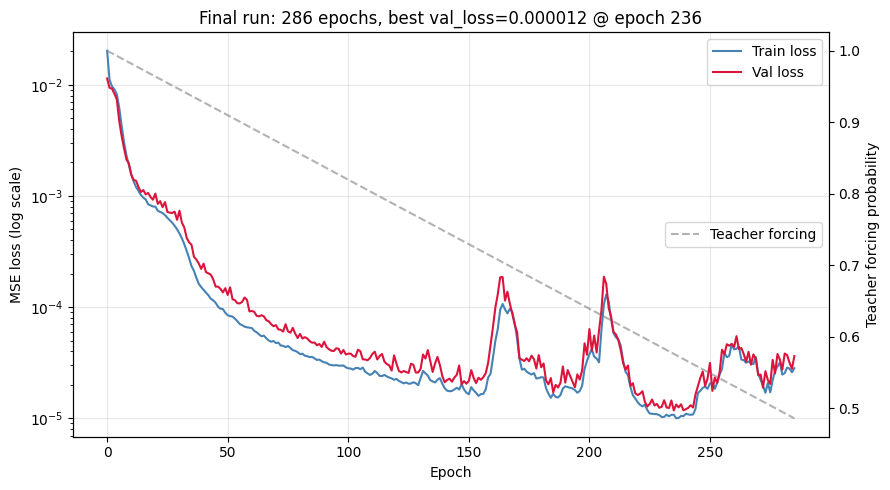

In [8]:
with open(FINAL_DIR / "history.json") as f:
    history = json.load(f)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(history["train_loss"], label="Train loss", color="steelblue")
ax1.plot(history["val_loss"], label="Val loss", color="crimson")
ax1.set_yscale("log")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE loss (log scale)")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(history["teacher_forcing"], color="gray", ls="--", alpha=0.6, label="Teacher forcing")
ax2.set_ylabel("Teacher forcing probability")
ax2.legend(loc="center right")

plt.title(f"Final run: {len(history['train_loss'])} epochs, best val_loss={final_metrics['best_val_loss']:.6f} @ epoch {final_metrics['best_epoch']}")
plt.tight_layout()
plt.show()

## Rest -> Motion -> Rest check, final model

Same check as before, now against the fully-trained final model
(val loss 0.0000118, ~70x lower than the 50-epoch side run's 0.000814).
Pure autoregressive rollout, no teacher forcing -- real deployment
conditions.

In [9]:
def active_cols(traj):
    left_travel = np.linalg.norm(traj[-1, :2] - traj[0, :2])
    right_travel = np.linalg.norm(traj[-1, 2:] - traj[0, 2:])
    return slice(0, 2) if left_travel > right_travel else slice(2, 4)


def autoregressive_rollout(model, traj_gt, target, moving_flag, device):
    traj_gt = traj_gt.unsqueeze(0).to(device)
    target_b = target.unsqueeze(0).to(device)
    moving_b = moving_flag.unsqueeze(0).to(device)
    state = model.init_state(batch_size=1, device=device)
    prev = traj_gt[:, 0]
    preds = [prev]
    with torch.no_grad():
        for t in range(1, traj_gt.shape[1]):
            moving_t = moving_b[:, t:t + 1]
            inp = torch.cat([prev, target_b, moving_t], dim=1)
            pred, state = model.forward_step(inp, state)
            preds.append(pred)
            prev = pred
    return torch.cat(preds, dim=0).cpu().numpy()


dataset = TrajectoryDataset(PROJECT_ROOT, pad_pre=cfg["pad_pre"], pad_post=cfg["pad_post"])
train_size = int(0.8 * len(dataset)); val_size = len(dataset) - train_size
_, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(cfg["seed"]))
print(f"Validation set: {len(val_dataset)} trajectories, {val_dataset[0][0].shape[0]} timesteps each")

Validation set: 100 trajectories, 140 timesteps each


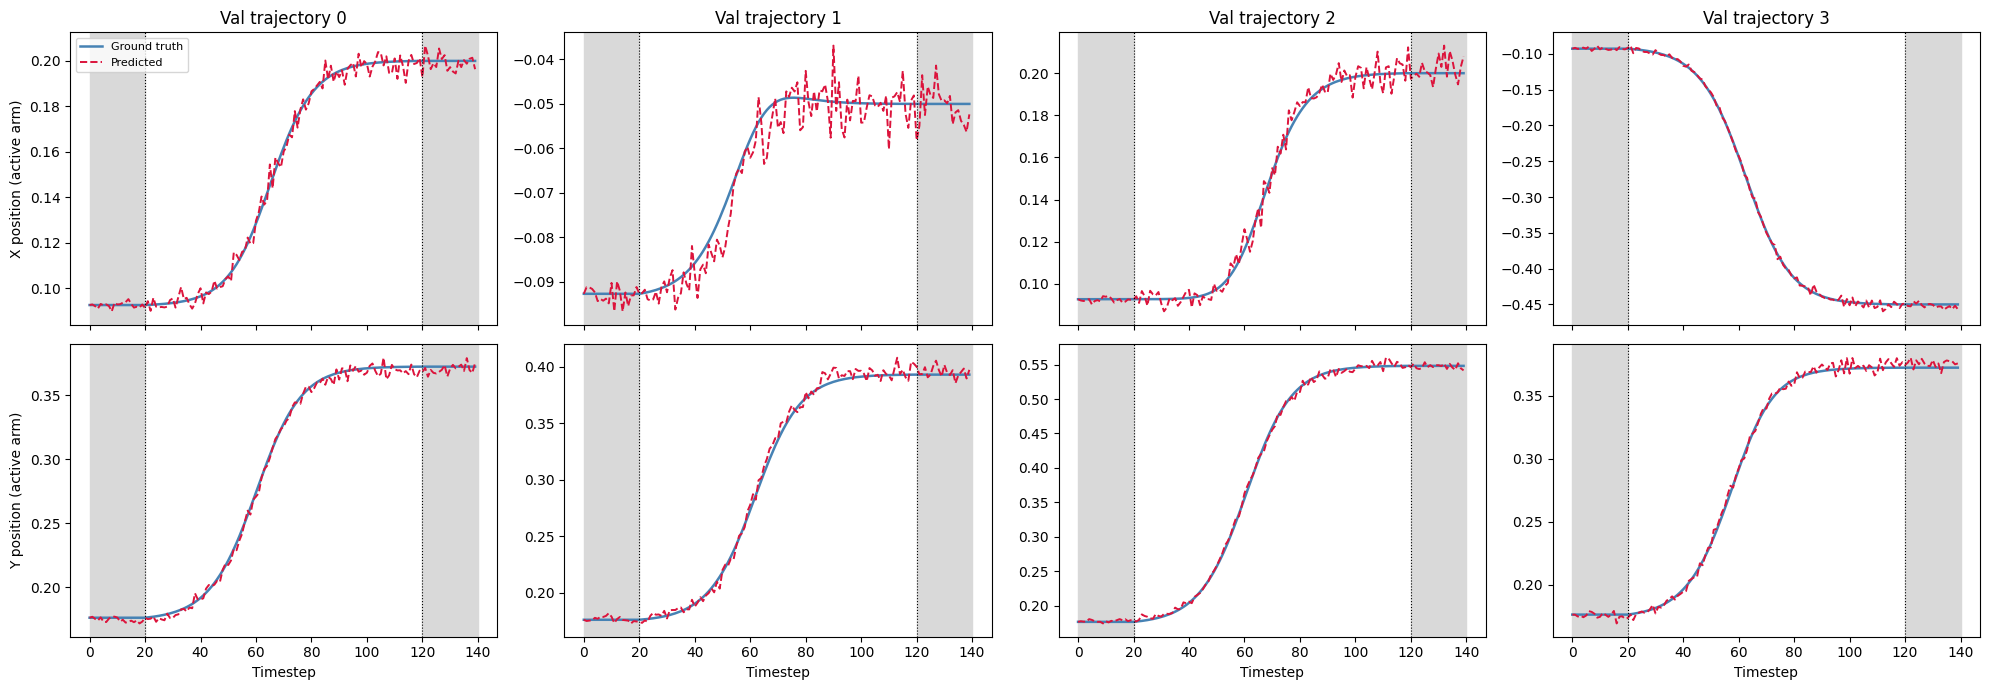

traj | rest-pre |x_err| |  motion mean err | rest-post |x_err| | pred drift (pre) | pred drift (post)
   0 |          0.00087 |          0.00441 |           0.00299 |          0.00446 |           0.01077
   1 |          0.00163 |          0.00600 |           0.00343 |          0.00579 |           0.01175
   2 |          0.00087 |          0.00560 |           0.00410 |          0.00399 |           0.01458
   3 |          0.00138 |          0.00421 |           0.00311 |          0.00701 |           0.01171


In [10]:
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(5 * n_show, 7), sharex=True)

pad_pre, pad_post = dataset.pad_pre, dataset.pad_post
region_stats = []

for i in range(n_show):
    traj_gt, target, moving_flag, _ = val_dataset[i]
    gt_traj = traj_gt.numpy()
    pred_traj = autoregressive_rollout(model, traj_gt, target, moving_flag, device)
    cols = active_cols(gt_traj)
    mflag = moving_flag.numpy()
    T = len(mflag)
    move_start = pad_pre
    move_end = pad_pre + int(mflag.sum())

    for row, (label, coord_idx) in enumerate([("X position (active arm)", 0), ("Y position (active arm)", 1)]):
        ax = axes[row, i]
        ax.axvspan(0, move_start, color="0.85", zorder=0)
        ax.axvspan(move_end, T, color="0.85", zorder=0)
        gt_col = gt_traj[:, cols][:, coord_idx]
        pred_col = pred_traj[:, cols][:, coord_idx]
        ax.plot(gt_col, color="steelblue", lw=1.8, label="Ground truth")
        ax.plot(pred_col, color="crimson", lw=1.4, ls="--", label="Predicted")
        ax.axvline(move_start, color="black", lw=0.8, ls=":")
        ax.axvline(move_end, color="black", lw=0.8, ls=":")
        if row == 0:
            ax.set_title(f"Val trajectory {i}")
        if i == 0:
            ax.set_ylabel(label)
        if row == 1:
            ax.set_xlabel("Timestep")
        if i == 0 and row == 0:
            ax.legend(fontsize=8, loc="upper left")

    rest_pre_err = np.abs(pred_traj[1:move_start, cols][:, 0] - gt_traj[1:move_start, cols][:, 0]).mean()
    rest_post_err = np.abs(pred_traj[move_end:, cols][:, 0] - gt_traj[move_end:, cols][:, 0]).mean()
    motion_err = np.linalg.norm(pred_traj[move_start:move_end, cols] - gt_traj[move_start:move_end, cols], axis=1).mean()
    pred_rest_pre_drift = np.abs(pred_traj[1:move_start, cols] - pred_traj[0, cols]).max()
    pred_rest_post_drift = np.abs(pred_traj[move_end:, cols] - pred_traj[-1, cols]).max()
    region_stats.append((i, rest_pre_err, motion_err, rest_post_err, pred_rest_pre_drift, pred_rest_post_drift))

plt.tight_layout()
plt.savefig(FINAL_DIR / "rest_motion_rest_check.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"{'traj':>4} | {'rest-pre |x_err|':>16} | {'motion mean err':>16} | {'rest-post |x_err|':>17} | "
      f"{'pred drift (pre)':>16} | {'pred drift (post)':>17}")
for row in region_stats:
    print(f"{row[0]:>4} | {row[1]:>16.5f} | {row[2]:>16.5f} | {row[3]:>17.5f} | {row[4]:>16.5f} | {row[5]:>17.5f}")

## A different set of held-out trajectories

This pipeline only has an 80/20 train/val split (no separate third "test"
set), so these are 4 more validation trajectories -- still never touched
by a gradient update -- picked at different indices spread across the
100-trajectory validation set, rather than the first 4 shown above.

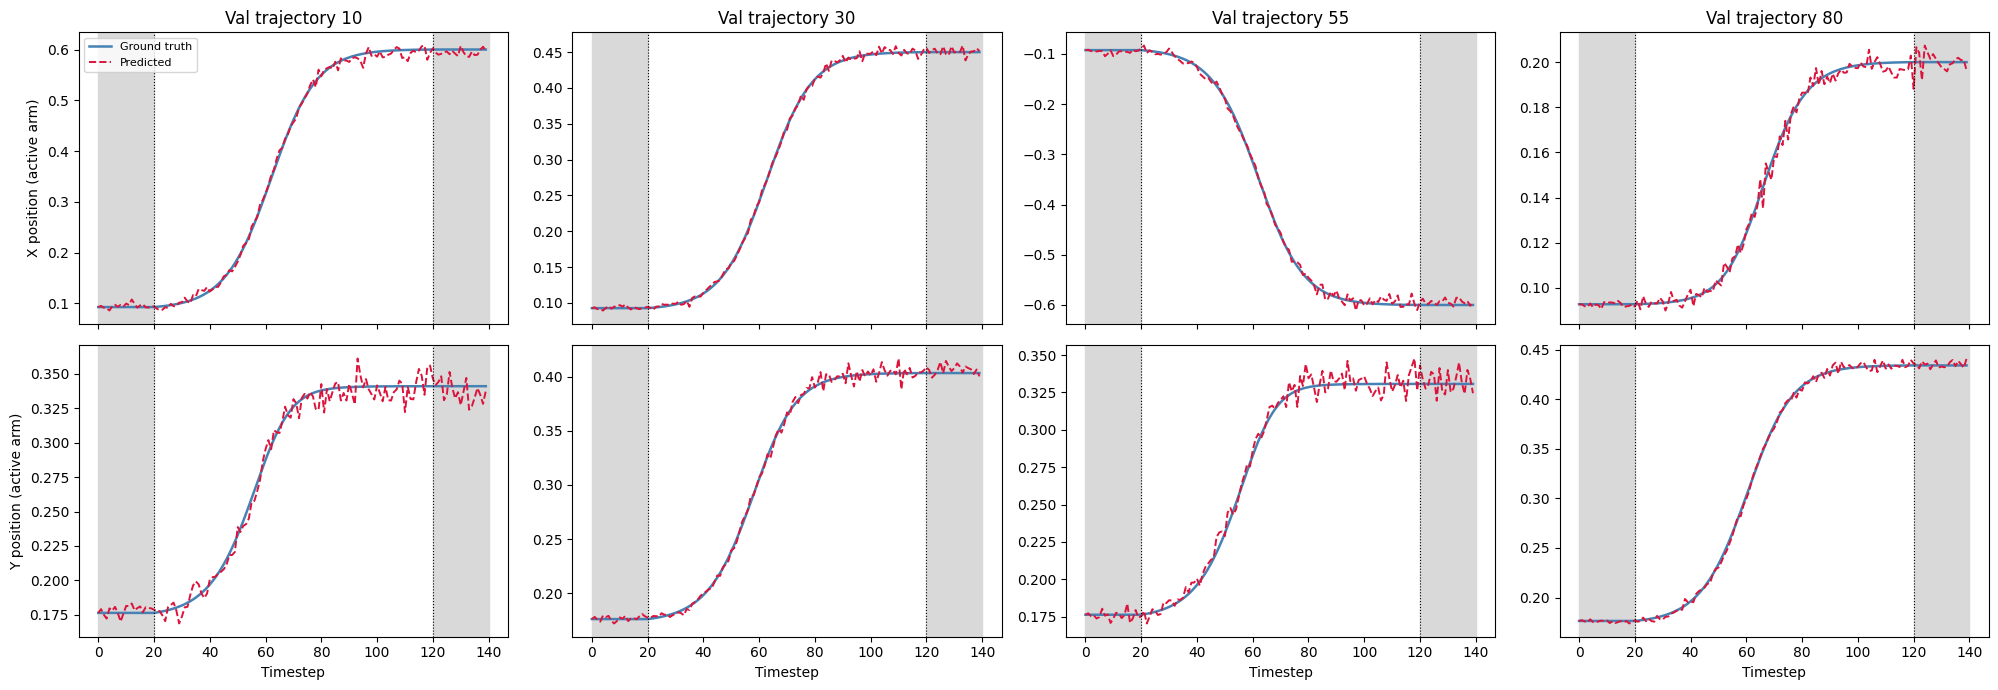

traj |    x_range |  motion mean err
  10 |     0.5073 |          0.00908
  30 |     0.3573 |          0.00475
  55 |     0.5073 |          0.00818
  80 |     0.1073 |          0.00387


In [11]:
new_indices = [10, 30, 55, 80]
fig, axes = plt.subplots(2, len(new_indices), figsize=(5 * len(new_indices), 7), sharex=True)

region_stats_2 = []
for col, i in enumerate(new_indices):
    traj_gt, target, moving_flag, _ = val_dataset[i]
    gt_traj = traj_gt.numpy()
    pred_traj = autoregressive_rollout(model, traj_gt, target, moving_flag, device)
    cols = active_cols(gt_traj)
    mflag = moving_flag.numpy()
    T = len(mflag)
    move_start = pad_pre
    move_end = pad_pre + int(mflag.sum())

    for row, (label, coord_idx) in enumerate([("X position (active arm)", 0), ("Y position (active arm)", 1)]):
        ax = axes[row, col]
        ax.axvspan(0, move_start, color="0.85", zorder=0)
        ax.axvspan(move_end, T, color="0.85", zorder=0)
        gt_col = gt_traj[:, cols][:, coord_idx]
        pred_col = pred_traj[:, cols][:, coord_idx]
        ax.plot(gt_col, color="steelblue", lw=1.8, label="Ground truth")
        ax.plot(pred_col, color="crimson", lw=1.4, ls="--", label="Predicted")
        ax.axvline(move_start, color="black", lw=0.8, ls=":")
        ax.axvline(move_end, color="black", lw=0.8, ls=":")
        if row == 0:
            ax.set_title(f"Val trajectory {i}")
        if col == 0:
            ax.set_ylabel(label)
        if row == 1:
            ax.set_xlabel("Timestep")
        if col == 0 and row == 0:
            ax.legend(fontsize=8, loc="upper left")

    x_gt = gt_traj[:, cols][:, 0]
    x_range = x_gt.max() - x_gt.min()
    motion_err = np.linalg.norm(pred_traj[move_start:move_end, cols] - gt_traj[move_start:move_end, cols], axis=1).mean()
    region_stats_2.append((i, x_range, motion_err))

plt.tight_layout()
plt.savefig(FINAL_DIR / "rest_motion_rest_check_batch2.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"{'traj':>4} | {'x_range':>10} | {'motion mean err':>16}")
for row in region_stats_2:
    print(f"{row[0]:>4} | {row[1]:>10.4f} | {row[2]:>16.5f}")